Install YOLOv8

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.1 MB/s eta 0:00:00


download traffic video sample

In [2]:
!wget https://github.com/ultralytics/yolov5/raw/master/data/videos/zidane.mp4

--2026-03-31 19:54:33--  https://github.com/ultralytics/yolov5/raw/master/data/videos/zidane.mp4
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-31 19:54:34 ERROR 404: Not Found.



import, test, upload video

In [3]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


yolov8

In [4]:
model = YOLO("yolov8n.pt")

In [5]:
#kaggle
import os

os.environ['KAGGLE_USERNAME'] = 'akhilatulasi'
os.environ['KAGGLE_KEY'] = 'KGAT_ff8aee80998743273abc345dcf366030'

In [6]:
!kaggle datasets list -s "traffic video dataset"

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
aryashah2k/highway-traffic-videos-dataset                         Highway Traffic Videos Dataset                        63389849  2021-07-09 11:52:30.370000          12307         55                1  
valentynsichkar/traffic-signs-dataset-in-yolo-format              Traffic Signs Dataset in YOLO format                 262150292  2020-04-03 22:25:16.090000          22207        157           0.9375  
kenjee/ken-jee-youtube-data                                       Ken Jee YouTube Data                                   6556461  2022-01-22 20:38:53.070000           6634        224          

In [7]:
!kaggle datasets download -d aryashah2k/highway-traffic-videos-dataset

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/highway-traffic-videos-dataset
License(s): CC0-1.0
100% 60.5M/60.5M [00:06<00:00, 9.65MB/s]



unzip

In [8]:
!unzip highway-traffic-videos-dataset.zip

Archive:  highway-traffic-videos-dataset.zip
  inflating: EvalSet.mat             
  inflating: EvalSet_test            
  inflating: EvalSet_train           
  inflating: ImageMaster             
  inflating: ImageMaster.mat         
  inflating: README_TRAFFICDB        
  inflating: info.txt                
  inflating: traffic_patches.mat     
  inflating: traffic_patches_reg.mat  
  inflating: video/cctv052x2004080516x01638.avi  
  inflating: video/cctv052x2004080516x01639.avi  
  inflating: video/cctv052x2004080516x01640.avi  
  inflating: video/cctv052x2004080516x01641.avi  
  inflating: video/cctv052x2004080516x01642.avi  
  inflating: video/cctv052x2004080516x01643.avi  
  inflating: video/cctv052x2004080516x01644.avi  
  inflating: video/cctv052x2004080516x01645.avi  
  inflating: video/cctv052x2004080516x01646.avi  
  inflating: video/cctv052x2004080516x01647.avi  
  inflating: video/cctv052x2004080516x01648.avi  
  inflating: video/cctv052x2004080516x01649.avi  
  inflating:

In [9]:
!ls

EvalSet.mat			    README_TRAFFICDB
EvalSet_test			    sample_data
EvalSet_train			    traffic_patches.mat
highway-traffic-videos-dataset.zip  traffic_patches_reg.mat
ImageMaster			    video
ImageMaster.mat			    yolov8n.pt
info.txt


In [10]:
!ls video

cctv052x2004080516x01638.avi  cctv052x2004080610x01889.avi
cctv052x2004080516x01639.avi  cctv052x2004080610x01890.avi
cctv052x2004080516x01640.avi  cctv052x2004080610x01891.avi
cctv052x2004080516x01641.avi  cctv052x2004080610x01892.avi
cctv052x2004080516x01642.avi  cctv052x2004080611x01894.avi
cctv052x2004080516x01643.avi  cctv052x2004080611x01895.avi
cctv052x2004080516x01644.avi  cctv052x2004080611x01896.avi
cctv052x2004080516x01645.avi  cctv052x2004080611x01897.avi
cctv052x2004080516x01646.avi  cctv052x2004080611x01898.avi
cctv052x2004080516x01647.avi  cctv052x2004080611x01899.avi
cctv052x2004080516x01648.avi  cctv052x2004080611x01900.avi
cctv052x2004080516x01649.avi  cctv052x2004080611x01901.avi
cctv052x2004080516x01650.avi  cctv052x2004080611x01902.avi
cctv052x2004080517x01652.avi  cctv052x2004080611x01903.avi
cctv052x2004080517x01653.avi  cctv052x2004080611x01904.avi
cctv052x2004080517x01654.avi  cctv052x2004080611x01905.avi
cctv052x2004080517x01655.avi  cctv052x2004080611x01906.a

In [11]:
from IPython.display import Video
Video("video/cctv052x2004080610x01886.avi")

colab browser is unable to work with .avi so we convert .avi to .mp4

In [12]:
!ffmpeg -i video/cctv052x2004080610x01886.avi traffic.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [13]:
from IPython.display import Video
Video("traffic.mp4", embed=True)

why did it not work when i put from IPython.display import Video
Video("traffic.mp4")

The difference is how the video is embedded in the notebook page.

What happened

When i ran:

Video("traffic.mp4")

Colab tried to link the video file externally.
Sometimes the browser cannot load it properly from the notebook environment, so nothing shows.

When you used
Video("traffic.mp4", embed=True)

embed=True tells Colab:

➡️ Put the video data directly inside the notebook output (base64 encoded).

So instead of referencing the file like this:

browser → file path → video

it becomes:

browser → notebook output → video data

Because the video is embedded directly in the output cell, the browser can always play it.

#RUN detection on ONE frame


0: 480x640 3 cars, 122.8ms
Speed: 13.5ms preprocess, 122.8ms inference, 50.9ms postprocess per image at shape (1, 3, 480, 640)
Found 3 objects

Class ID: 2, Confidence: 0.6955699324607849
Class ID: 2, Confidence: 0.5551069378852844
Class ID: 2, Confidence: 0.5212363004684448


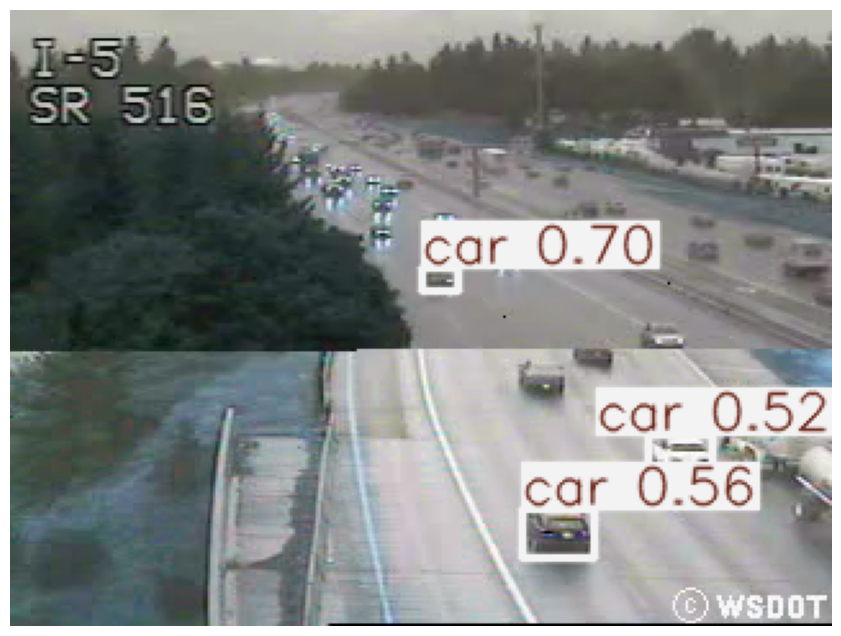

In [14]:
#detecting all objects in one frame
import cv2

#readin 1st frame
cap = cv2.VideoCapture("traffic.mp4")
ret, frame = cap.read()
cap.release()

#run
results = model(frame, conf=0.5)
#show detection
print(f"Found {len(results[0].boxes)} objects\n")

for box in results[0].boxes:
  class_id = int(box.cls[0])
  confidence = float(box.conf[0])
  class_name = results[0].names[class_id]
  print(f"Class ID: {class_id}, Confidence: {confidence}")

# draw box frame and display
frame_with_boxes = results[0].plot()
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
plt.imshow(frame_with_boxes)
plt.axis("off")
plt.show()


yayyyy
#Detect object in all frames
1102

In [15]:
import cv2
#the setup
cap = cv2.VideoCapture("traffic.mp4")  #Open video
all_detections = []                    #Create empty list (like a blank notebook)
frame_num = 0                          #Start frame counter at 0

print("Processing Video....\n")

#the loop
while True:                     #- `while True:` = keep going forever +> its an infinate loop ig until the video ends
  ret, frame = cap.read()       #- `ret, frame = cap.read()` = read ONE frame  -> ret meaning like returning with a frame
  if not ret:                   #- `if not ret:` = if no more frames, STOP ->if it returns with no frame is what it means ig(bob said that)
    break
#Frame 0 → Frame 1 → Frame 2 → ... → Frame 8999 → STOP

  #running yolo detection
  results = model(frame, conf=0.5, verbose=False)
  #Run YOLO on this ONE frame , conf=0.5 => only 50%+ confident detections, verbose=False => don't print spam(debugging msges)-> verbose = true will print out all the debugging msges essentially.

  #detecting
  frame_data = {                #- Create a folder for this frame
      'frame_num' : frame_num,
      'detections' : []         #- Empty list for detections (we'll fill it next)
  }
# for the 1st iteration visuall wil be
#Frame 0:
#  ├─ frame_num: 0
#  └─ detections: []

#Loop Through Each Detection
  for box in results[0].boxes:
    #If YOLO found 5 cars in this frame, loop 5 times, Each loop, box = ONE car
    #Extract Information
    class_id = int(box.cls[0])                    # What type? (0=person, 2=car, etc)
    confidence = float(box.conf[0])               # How confident? (0.87 = 87%)
    class_name = results[0].names[class_id]       # Get the name ('car')
    x1,y1,x2,y2 = box.xyxy[0].tolist()            # Where is it? (coordinates)
#**Visual of box coordinates:**
#(x1, y1) __________
#         |        |
#         | CAR    |
#         |________|
#                 (x2, y2)


#Save This Detection
    frame_data['detections'].append({        #Add this detection to the list
        'class' : class_name,
        'confidence' : confidence,
        'bbox' : [x1,y1,x2,y2]              #Format: {'class': 'car', 'confidence': 0.87, 'bbox': [100, 200, 500, 400]}
    })

 #Save Frame to Master List
  all_detections.append(frame_data)         #- Add this entire frame's data to `all_detections
  #**Now all_detections looks like:**
#all_detections = [
#    Frame 0: {detections: [car1, car2, truck1, ...]},
#    Frame 1: {detections: [car1, car2, ...]},
#    Frame 2: {detections: [person1, car1, ...]},
#    ...
#]

#Increment Counter, Move to next frame
  frame_num += 1
  if frame_num % 30 == 0:                   #Print progress every 30 frames
    print(f"processed {frame_num} frames")

#Cleanup
  cap.release()

  total_detections = sum(len(d['detections']) for d in all_detections)
  print(f"\n ~ Done!")
  print(f"Found {total_detections} objects in {frame_num} frames")

  #Close the video file, Count total detections across all frames


Processing Video....


 ~ Done!
Found 3 objects in 1 frames


cap = cv2.VideoCapture(VIDEO_PATH)Open the video-- filefps = cap.get(cv2.CAP_PROP_FPS)Get frames per second--frame_width = int(cap.get(...))Get width in pixels--frame_height = int(cap.get(...))Get height in pixels--total_frames = int(cap.get(...))Get total number of frames--ret, frame = cap.read()Read one frame (ret=True if success)--cv2.cvtColor(..., COLOR_BGR2RGB)Convert colors from BGR to RGB--plt.imshow(frame_rgb)Display the frame--cap.release()Close the file

#Draw Boxes On Video And Save

In [21]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("traffic.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

#now settign up the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output.mp4', fourcc, fps, (width, height))

frame_num = 0
print("Drawing boxes....\n")

while True:
  ret, frame = cap.read()
  if not ret:
    break

  #now get detections for this frame
  if frame_num < len(all_detections):
    detections = all_detections[frame_num]['detections']
  else:
    detections = []

  #drawing each detection
  for det in detections:
    x1, y1, x2, y2 = [int(v) for v in det['bbox']]
    confindence = det['confidence']
    class_name = det['class']


    #draw a green rectagle box
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    #draw a label
    label = f"{class_name} {confidence:.0%}"
    cv2.putText(frame, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  #writing frame to the output video
  out.write(frame)
  frame_num += 1
  if frame_num % 30 == 0:
    print(f"Frame {frame_num}")
cap.release()
out.release()

print("\n yayy video saved as 'output.mp4'")



Drawing boxes....

Frame 30

 yayy video saved as 'output.mp4'


#Statistics and Analysis

In [22]:
#Analysing the detections
from collections import Counter
all_classes = []
all_confidences = []

for frame_data in all_detections:
  for det in frame_data['detections']:
    all_classes.append(det['class'])
    all_confidences.append(det['confidence'])


#print statistics
print("="*50)
print("Detection Statistics")
print("="*50)
print(f"Total detections: {len(all_classes)}")
print(f"Average confidence: {sum(all_confidences)/len(all_confidences):.2%}")
print(f"Min confidence: {min(all_confidences):.2%}")
print(f"Max confidence: {max(all_confidences):.2%}")
print(f"\nDetections by class:")

class_counts = Counter(all_classes)
for class_name, count in class_counts.most_common():
  percentage = 100 * count / len(all_classes)
  print(f"{class_name:15}: {count:4} ({percentage:5.1f}%)")

frames_with_detections = sum(1 for d in all_detections if d['detections'])
print(f"\nFrames with objects: {frames_with_detections} / {len(all_detections)}")
print("="*50)

Detection Statistics
Total detections: 3
Average confidence: 59.06%
Min confidence: 52.12%
Max confidence: 69.56%

Detections by class:
car            :    3 (100.0%)

Frames with objects: 1 / 1


# Filtering and Creating A New Video

In [23]:
import cv2

# settings -> change the filter
CONFIDENCE_THRESHOLD = 0.6
TARGET_CLASSES = ['car', 'truck', 'bus']

cap = cv2.VideoCapture("traffic.mp4")
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output_filtered.mp4', fourcc, fps, (width, height))

frame_num = 0
print("Creating filtered Video.....\n")

while True:
  ret, frame = cap.read()
  if not ret:
    break

  if frame_num < len(all_detections):
    detections = all_detections[frame_num]['detections']
  else:
    detections = []

  #filtering -> only keeping high confdence and target classes.
  filtered = [
      det for det in detections
      if det['confidence'] >= CONFIDENCE_THRESHOLD and det['class'].lower() in [c.lower() for c in TARGET_CLASSES]
  ]

  #drawing FILTERED DETECTIONS
  for det in filtered:
    x1, y1, x2, y2 = [int(v) for v in det['bbox']]
    confidence = det['confidence']
    class_name = det['class']

    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = f"{class_name} {confidence:.0%}"
    cv2.putText(frame, label, (x1, y1 -5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0),2)

  out.write(frame)
  frame_num += 1

  if frame_num % 30 == 0:
    print(f"Frame {frame_num}")

cap.release()
out.release()

print("\n yayy video saved as 'output_filtered.mp4'")


Creating filtered Video.....

Frame 30

 yayy video saved as 'output_filtered.mp4'
